In [1]:
# importing packages
import finesse
import numpy as np
import matplotlib.pyplot as plt


In [2]:
# creating model
model = finesse.Model()
model.parse("""
    # Creating a laser, modulating its phase and amplitude (RFAM), splitting the beam, and sending it into the cavity: 
    l laser P=1
    mod pm1 100M 0.9 order=2 mod_type=pm phase=0.0
    mod am1 100M 0.1 order=1 mod_type=am phase=0.0

    bs bs1 R=0.5 T=0.5
    m inm R=0.9 T=0.1
    s scav portA=inm.p2 portB=outm.p1 L=0.5
    m outm R=0.9 T=0.1

    # Creating photodetectors:
    pd pdtrans outm.p2.o
    pd pdrefl inm.p1.o
    # Now for the demodulation pd. 
    # I have used preeminence to determine that the optimal phase MUST be 2 degrees
    # (actually just look ahead to see how I found the optimal phase)
    pd1 pdh node=inm.p1.o f=pm1.f phase=2
    
""")
# Creating a deepcopy of the above model to link together the components
onetone = model.deepcopy()
onetone.parse("""
    link(laser,pm1,am1,bs1,inm)
""")

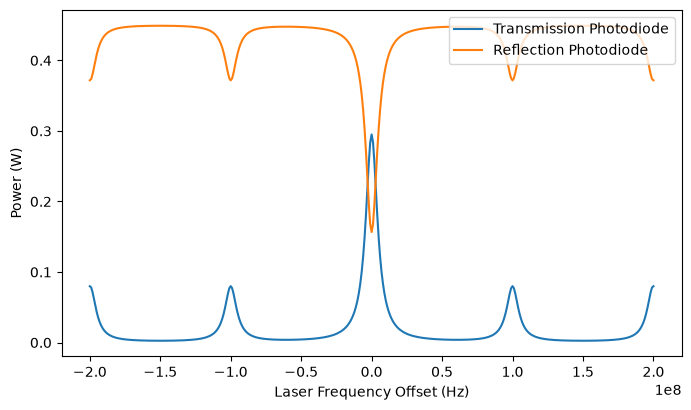

In [3]:
# Plotting frequency sweep
onetone.parse("xaxis(laser.f, lin, -200M, 200M, 400)")

# Run the model and create x data array
sol = onetone.run()
solxdata = np.squeeze(sol.x)  # squeeze cuts out a 1 entry array element that appears to exist to make our lives difficult

plt.figure(figsize=(8,4.5))
plt.plot(solxdata, sol["pdtrans"], label="Transmission Photodiode")
plt.plot(solxdata, sol["pdrefl"], label="Reflection Photodiode")
plt.xlabel("Laser Frequency Offset (Hz)")
plt.ylabel("Power (W)")
plt.legend(loc = "upper right")


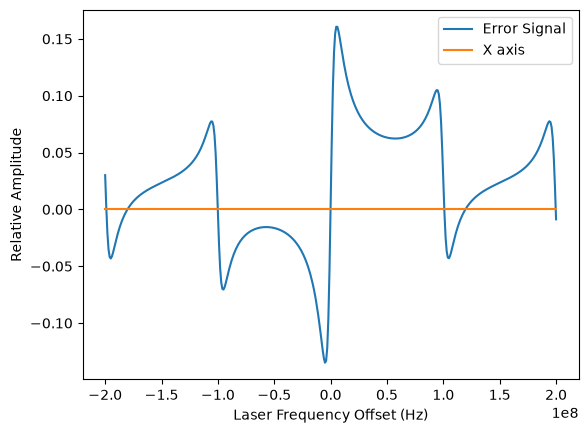

In [4]:
# Plotting error function
plt.plot(solxdata, sol["pdh"], label="Error Signal")
plt.plot(solxdata,np.zeros(len(solxdata)),label="X axis")
plt.legend(loc='upper right')
plt.xlabel("Laser Frequency Offset (Hz)")
plt.ylabel("Relative Amplitude")
plt.show()

In [5]:
# Creating a deepcopy of model to add in more modulators, and a pd2
twotone = model.deepcopy()

twotone.parse("""
    # add in the modulators
    mod pm2 20M 0.9 order=2 mod_type=pm phase=0.0
    mod am2 pm2.f 0.1 order=1 mod_type=am phase=0.0
    
    # ... and a new photodiode 
    # pd2 demodulates at the first frequency, then the second
    pd2 pdh2tone inm.p1.o pm1.f 2 2*pm2.f 60

    # Glue it all together
    link(laser,pm1,am1,pm2,am2,bs1,inm)

""")

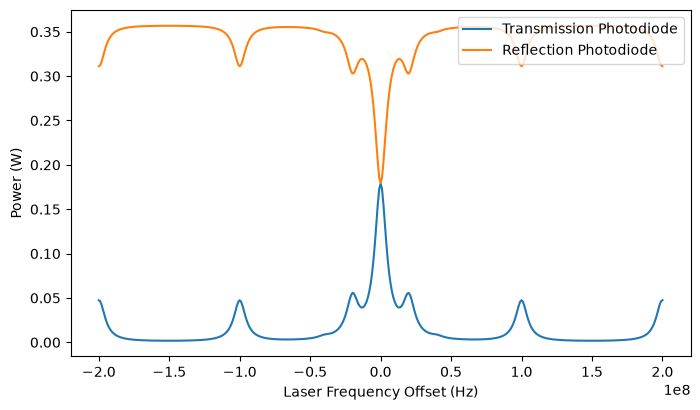

In [6]:
twotone.parse("xaxis(laser.f, lin, -200M, 200M, 400)")

sol2tone = twotone.run()
sol2tonexdata = np.squeeze(sol2tone.x)

plt.figure(figsize=(8,4.5))
plt.plot(sol2tonexdata, sol2tone["pdtrans"], label="Transmission Photodiode")
plt.plot(sol2tonexdata, sol2tone["pdrefl"], label="Reflection Photodiode")
plt.xlabel("Laser Frequency Offset (Hz)")
plt.ylabel("Power (W)")
plt.legend(loc = "upper right")

In [7]:
# Lets find the optimal demodulation phase for the first demod
# This function will do that for a given model at a given frequency
# Please note that you MUST type in the demod frequency in scientific notation
    # i.e. 100e6 will work, but 100M will result in a "SyntaxError: invalid decimal literal" error

def find_optimal_demod_phase(finmodel,demod_freq,verbose=True):
    # Create an array of phases from 0 to 90
    phases = np.arange(0,91,1)
    # For each angle, create a pd at that angle, and at the demod frequency
    for phase in phases:
        finmodel.parse(f"pd1 demod_pdh{phase:.0f} node=inm.p1.o f={demod_freq} phase={phase:.0f}")
    # Run the model within the slope of the error function
    out = finmodel.run("xaxis(laser.f,lin,-100k,100k,2)")
    # Create an empty array
    grad=[]
    # For each angle, fill the empty array with the slope for each angle
    for phase in phases:
        var = out[f'demod_pdh{phase}']
        grad.append((var[0] - var[-1])/2*100e3)
    grad=np.array(grad)
    # Now find the array index that the max slope occurs at
    idxmax = np.argmax(np.abs(grad))
    print(f'Maximum error signal gradient occurs at {phases[idxmax]} degrees')
    # Now remove all the demodulation pds we made!
    for el in finmodel.elements:
        if el.startswith('demod_pdh'):
            finmodel.remove(el)
            if verbose==True:
                print(f'removed {el}')

find_optimal_demod_phase(twotone, 100e6, verbose=False)

Maximum error signal gradient occurs at 2 degrees


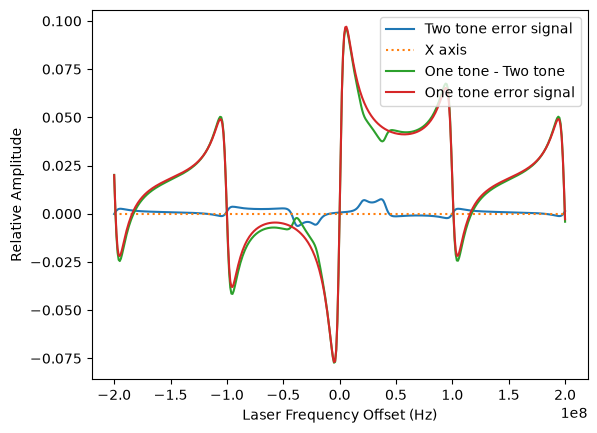

In [8]:
plt.plot(sol2tonexdata, sol2tone["pdh2tone"], label="Two tone error signal")
plt.plot(sol2tonexdata,np.zeros(len(sol2tonexdata)), label="X axis",linestyle="dotted")
plt.plot(sol2tonexdata,sol2tone["pdh"]-sol2tone["pdh2tone"], label="One tone - Two tone")
plt.plot(sol2tonexdata,sol2tone["pdh"], label="One tone error signal")
plt.xlabel("Laser Frequency Offset (Hz)")
plt.ylabel("Relative Amplitude")
plt.legend(loc="upper right")
plt.show()